<a href="https://colab.research.google.com/github/KhusbuBubna123/Repository3/blob/main/MoviewSentimentAnlaysis_CountVectorizer_Mutinomial_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
df = pd.read_csv("IMDBDataset.csv",names=['Movie Review','Sentiment'])
df.head(10)

,Movie Review,Sentiment
0,review,sentiment
1,One of the other reviewers has mentioned that ...,positive
2,A wonderful little production. <br /><br />The...,positive
3,I thought this was a wonderful way to spend ti...,positive
4,Basically there's a family where a little boy ...,negative
5,"Petter Mattei's ""Love in the Time of Money"" is...",positive
6,"Probably my all-time favorite movie, a story o...",positive
7,I sure would like to see a resurrection of a u...,positive
8,"This show was an amazing, fresh & innovative i...",negative
9,Encouraged by the positive comments about this...,negative


In [6]:
df = df.drop(df.index[0])

In [7]:
df.shape

(50000, 2)

In [8]:
df['Sentiment'].value_counts()

,count
Sentiment,
positive,25000
negative,25000


In [9]:
df['Review_Length'] = df['Movie Review'].apply(len)
df.head()

,Movie Review,Sentiment,Review_Length
1,One of the other reviewers has mentioned that ...,positive,1761
2,A wonderful little production. <br /><br />The...,positive,998
3,I thought this was a wonderful way to spend ti...,positive,926
4,Basically there's a family where a little boy ...,negative,748
5,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [10]:
# Longest Movie Review
df.loc[df['Review_Length'] == df['Review_Length'].max(), 'Movie Review'].values[0]

'Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to help his brother, but the referee restrained him while Benoit and Guerrero ganged up on him in the corner. With Benoit stomping away on Bubba, Guerrero set up a table outside. Spike dashed into the ring and somersaulted over the top rope onto Guerrero on the outside! After recovering and taking care of Spike, Guerrero slipped a table into the ring and helped the Wolverine set it up. The tandem then set up for a double superplex from the middle rope which would have put Bubba through the table, bu

In [65]:
# Shortest Movie Review
df.loc[df['Review_Length'] == df['Review_Length'].min(), 'Movie Review'].values[0]

'Read the book, forget the movie!'

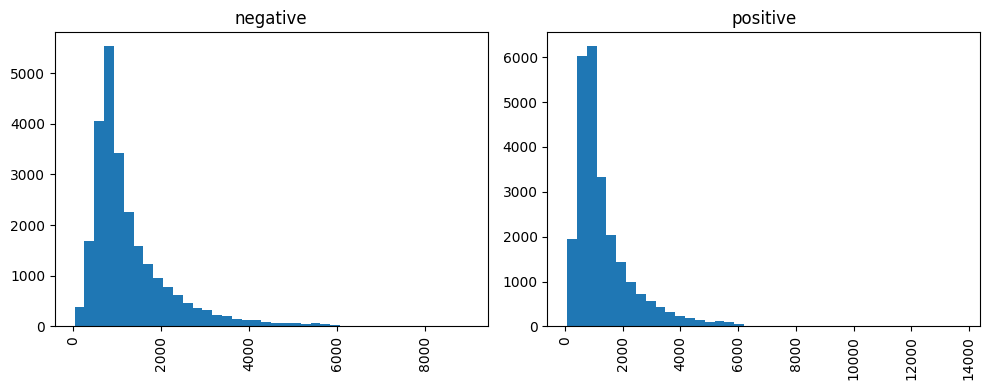

In [66]:
# Distribution of message lengths by class
df.hist(column='Review_Length',by='Sentiment',bins=40, figsize=(10, 4))
plt.tight_layout()
plt.show()

In [38]:
''' df['Target'] = df['Sentiment'].map({'positive': 1, 'negative': 0})
df[['Sentiment', 'Target']].head(8) '''

" df['Target'] = df['Sentiment'].map({'positive': 1, 'negative': 0})\ndf[['Sentiment', 'Target']].head(8) "

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])

print(df.head(7))

                                        Movie Review Sentiment  Review_Length  \
1  One of the other reviewers has mentioned that ...  positive           1761   
2  A wonderful little production. <br /><br />The...  positive            998   
3  I thought this was a wonderful way to spend ti...  positive            926   
4  Basically there's a family where a little boy ...  negative            748   
5  Petter Mattei's "Love in the Time of Money" is...  positive           1317   
6  Probably my all-time favorite movie, a story o...  positive            656   
7  I sure would like to see a resurrection of a u...  positive            726   

   Sentiment_Encoded  
1                  1  
2                  1  
3                  1  
4                  0  
5                  1  
6                  1  
7                  1  


#Text Pre-processing

In [12]:
df['Movie Review'] = df['Movie Review'].str.replace('<br />', '', regex=False)

In [13]:
# Removing punctuation and converting to lower case.

def remove_punct(text):
    return ''.join(ch for ch in text if ch not in string.punctuation)

def convert_lowercase(text):
  return text.lower()

df['Review_clean'] = df['Movie Review'].apply(remove_punct)
df['Review_clean'] = df['Review_clean'].apply(convert_lowercase)
df[['Movie Review', 'Review_clean']].head(3)

,Movie Review,Review_clean
1,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
2,A wonderful little production. The filming tec...,a wonderful little production the filming tech...
3,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


#Splitting into Train and Test Data

In [169]:
X = df['Review_clean'].values
Y = df['Sentiment_Encoded'].values.astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [170]:
print('Train size:', len(X_train))
print('Test  size:', len(X_test))

Train size: 40000
Test  size: 10000


#Vectorisation — Bag of Words (CountVectorizer)

In [171]:
#Count Vectorize and removing stopwords.

Count_Vectorizer = CountVectorizer(stop_words='english')
X_train = Count_Vectorizer.fit_transform(X_train)  # fit + transform
X_test = Count_Vectorizer.transform(X_test)        # transform only — same vocabulary

print('Vocabulary size:', len(Count_Vectorizer.vocabulary_))
print('Train shape    :', X_train.shape)
print('Test  shape    :', X_test.shape)        # transform only — same vocabulary

Vocabulary size: 191834
Train shape    : (40000, 191834)
Test  shape    : (10000, 191834)


In [172]:
feature_names = CV.get_feature_names_out()
print('Total features:', len(feature_names))

Total features: 191834


In [173]:
print('Sample features  :', feature_names[:20])

Sample features  : ['00' '000' '00000001' '000001' '0001' '00015' '001' '0010' '002'
 '00383042' '007' '0079' '007s' '007the' '0080' '0083' '009' '00s'
 '00schneider' '01']


#Training a model — MultinomialNB

In [174]:
NB = MultinomialNB()
NB.fit(X_train, Y_train)    #alpha is used for Laplace smooothing.

MultinomialNB()

In [175]:
Y_Pred = NB.predict(X_test)
print(Y_Pred.tolist())

[1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 

In [176]:
#1-Positive    0-Negative
original_categories = le.inverse_transform(Y_Pred)
print(original_categories)

['positive' 'positive' 'negative' ... 'positive' 'negative' 'negative']


In [177]:
accuracy = accuracy_score(Y_test, Y_Pred) * 100
print(f'MultinomialNB Accuracy: {accuracy:.2f}%')

MultinomialNB Accuracy: 85.78%


In [178]:
print(classification_report(Y_test, Y_Pred, target_names=['positive', 'negative']))

              precision    recall  f1-score   support

    positive       0.85      0.87      0.86      4961
    negative       0.87      0.84      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [161]:
#confusion_matrix(Y_test,Y_Pred)

In [179]:
ConfusionMatrix = pd.DataFrame(
    confusion_matrix(Y_test,Y_Pred),
    index=['Actual review positve', 'Actual review negative'],
    columns=['Predicted review positve', 'Predicted review negative']
)

# Display the DataFrame
ConfusionMatrix

,Predicted review positve,Predicted review negative
Actual review positve,4331,630
Actual review negative,792,4247


In [126]:
#Testing on a New Movie Review.

In [192]:
def classify_message(movie_review):
    movie_review = movie_review.replace("<br>", "")
    cleaned  = remove_punct(movie_review)
    cleaned = convert_lowercase(cleaned)
    features = Count_Vectorizer.transform([cleaned])
    Pred = NB.predict(features)
    if(Pred == 1):
        Sentiment='Positive Sentiment'
    else:
      Sentiment='Negative Sentiment'
    return Sentiment

In [193]:
Movie_Review1='''One of the other reviewers has mentioned that after watching just 1 Oz
episode you'll be hooked. They are right, as this is exactly what happened with me.
<br /><br />The first thing that struck me about Oz was its brutality and unflinching scene
s of violence, which set in right from the word GO. Trust me, this is not a show for the faint
 hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is
 hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname
 given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City,
 an experimental section of the prison where all the cells have glass fronts and face inwards,
  so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas,
  Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings
  and shady agreements are never far away.<br /><br />I would say the main appeal of the show
   is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted
   for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode
I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched
more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence.
Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll
kill on order and get away with it, well mannered, middle class inmates being turned into prison
bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable
 with what is uncomfortable viewing....thats if you can get in touch with your darker side.'''

In [194]:
classify_message(Movie_Review1)

'Positive Sentiment'

In [196]:
Movie_Review2='''It's not well shot, well written or well acted but it has to be the most addictive show
 I've seen since Twin Peaks. Every single revelation is timed so well that you have to see the next episode
  to get any kind of closure. They have even slowed down the pace of the show where they only reveal tiny
  amounts of information per episode however it feels like they've just told you everything you wanted to know.
   However some of the acting is just about awful and some of the duologue is downright brutal. Some characters
   are very two dimensional. The more experienced actors like Locke and Ecko really stand out over actors who
    play Jack, Kate, Sayid and so on. The development of the show can also be very frustrating as the following
    episode may not show what the previous episode lead up to. Annoying side plots have become part of the story
    that sometimes tell you nothing. However, the second season has developed to a point where back stories reveal
    more about the island than they had previously. All in all its a great show but not perfect.'''

In [197]:
classify_message(Movie_Review2)

'Negative Sentiment'

In [198]:
Movie_Review3='''A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting,
 and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only
 ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams'
 diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of
 the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which,
 rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with
 the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly
 well done.'''

In [199]:
classify_message(Movie_Review3)

'Positive Sentiment'

#TF-IDF vectorisation + BernoulliNB

NameError: name 'df' is not defined

NameError: name 'X_train' is not defined